# Импорт библиотек

In [28]:
from __future__ import annotations

from decision_tree import DecisionTreeClassifier

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

In [29]:
SEED = 42

# Обучение

In [30]:
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('y_train distribution:', np.bincount(y_train))
print('y_test distribution:', np.bincount(y_test))

X_train: (455, 30) X_test: (114, 30)
y_train distribution: [170 285]
y_test distribution: [42 72]


In [31]:
params = dict(max_depth=4, min_samples_split=4, min_samples_leaf=2)

custom_model = DecisionTreeClassifier(**params).fit(X_train, y_train)
sk_model = SklearnDecisionTreeClassifier(criterion='gini', random_state=SEED, **params).fit(X_train, y_train)

In [32]:
y_pred_custom_train = custom_model.predict(X_train)
y_pred_sklearn_train = sk_model.predict(X_train)

y_pred_custom = custom_model.predict(X_test)
y_pred_sklearn = sk_model.predict(X_test)


In [33]:
def metrics_row(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float | str]:
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='binary'),
        'recall': recall_score(y_true, y_pred, average='binary'),
        'f1': f1_score(y_true, y_pred, average='binary'),
    }


In [34]:
results = pd.DataFrame([
    metrics_row('Custom DecisionTreeClassifier', y_test, y_pred_custom),
    metrics_row('sklearn DecisionTreeClassifier', y_test, y_pred_sklearn),
])

results

,model,accuracy,precision,recall,f1
0,Custom DecisionTreeClassifier,0.947368,0.958333,0.958333,0.958333
1,sklearn DecisionTreeClassifier,0.929825,0.957143,0.930556,0.943662


In [35]:
accuracy_results = pd.DataFrame([
    {
        'model': 'Custom DecisionTreeClassifier',
        'train_accuracy': accuracy_score(y_train, y_pred_custom_train),
        'test_accuracy': accuracy_score(y_test, y_pred_custom),
    },
    {
        'model': 'sklearn DecisionTreeClassifier',
        'train_accuracy': accuracy_score(y_train, y_pred_sklearn_train),
        'test_accuracy': accuracy_score(y_test, y_pred_sklearn),
    },
])

accuracy_results


,model,train_accuracy,test_accuracy
0,Custom DecisionTreeClassifier,0.989011,0.947368
1,sklearn DecisionTreeClassifier,0.989011,0.929825


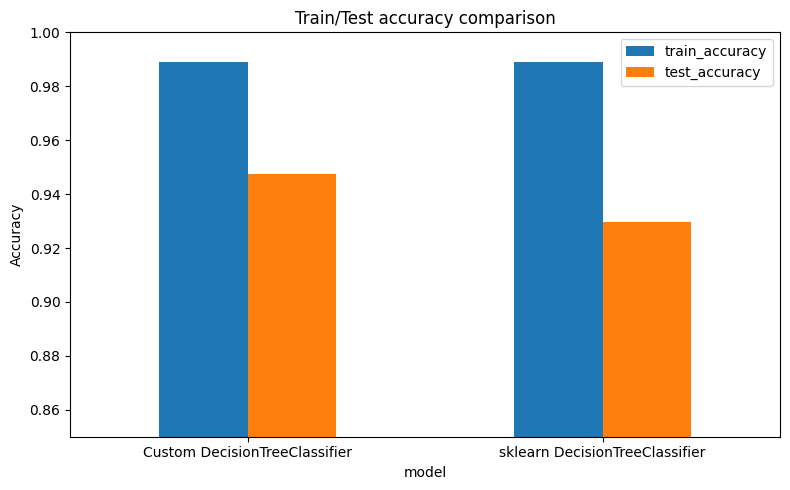

In [36]:
plot_df = accuracy_results.set_index('model')
ax = plot_df.plot(kind='bar', figsize=(8, 5), rot=0)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Train/Test accuracy comparison')
plt.tight_layout()
plt.show()


In [37]:
comparison = pd.DataFrame({
    'y_true': y_test[:20],
    'custom_pred': y_pred_custom[:20],
    'sklearn_pred': y_pred_sklearn[:20],
})
comparison

,y_true,custom_pred,sklearn_pred
0,0,0,0
1,1,1,1
2,0,0,0
3,1,1,1
4,0,0,0
5,1,1,1
6,1,1,1
7,0,0,0
8,0,0,0
9,0,0,0


In [38]:
agreement = np.mean(y_pred_custom == y_pred_sklearn)
print(f'Доля совпадения предсказаний custom vs sklearn: {agreement:.4f}')

Доля совпадения предсказаний custom vs sklearn: 0.9825


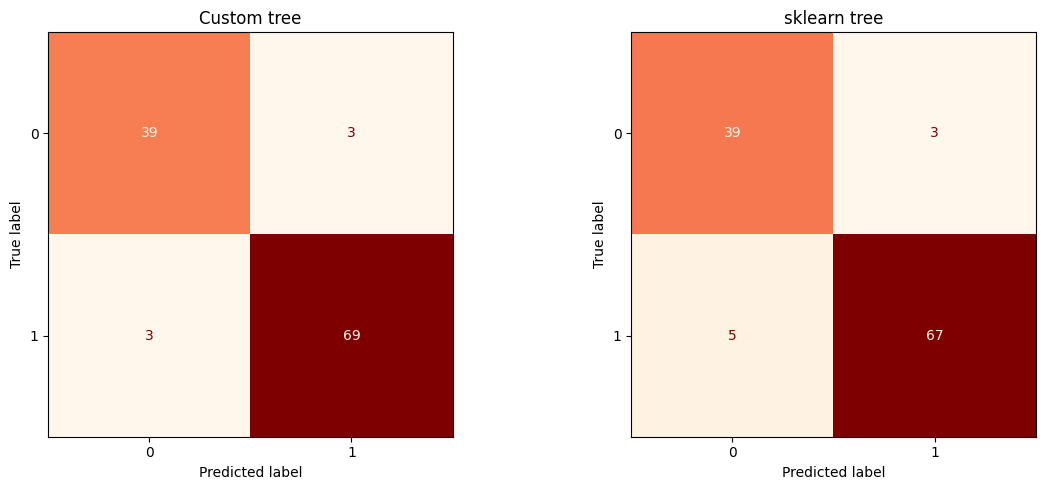

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_custom, ax=axes[0], colorbar=False, cmap='OrRd')
axes[0].set_title('Custom tree')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_sklearn, ax=axes[1], colorbar=False, cmap="OrRd")
axes[1].set_title('sklearn tree')

plt.tight_layout()
plt.show()